In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [3]:
#cashflow

def cash_flows(face, coupon_rate, years, freq=2):
    """Periodic coupon cash flows; face value added to the final period."""
    n = int(round(years * freq))
    cpn = face * coupon_rate / freq
    cf = np.full(n, cpn, dtype=float)
    cf[-1] += face
    t = np.arange(1, n + 1)
    return t, cf

# price, yield, current yield, accrued interest

def bond_price(face, coupon_rate, years, ytm, freq=2):
    """Price = present value of all cash flows discounted at YTM."""
    t, cf = cash_flows(face, coupon_rate, years, freq)
    r = ytm / freq
    return float(np.sum(cf / (1 + r) ** t))

def ytm(price, face, coupon_rate, years, freq=2):
    """Solve for the yield to maturity that makes PV(cash flows) == price."""
    f = lambda y: bond_price(face, coupon_rate, years, y, freq) - price
    return brentq(f, -0.9999, 5.0, xtol=1e-10)

def current_yield(face, coupon_rate, price):
    return (face * coupon_rate) / price

def accrued_interest(face, coupon_rate, freq, frac_elapsed):
    """frac_elapsed = days since last coupon / days in coupon period (0..1).
       Dirty price = clean price + accrued interest."""
    return face * coupon_rate / freq * frac_elapsed


In [4]:
#duration & convexity (Fixed Income)

def durations(face, coupon_rate, years, ytm_, freq=2):
    t, cf = cash_flows(face, coupon_rate, years, freq)
    r = ytm_ / freq
    pv = cf / (1 + r) ** t
    price = pv.sum()
    mac_years = (np.sum(t * pv) / price) / freq            # Macaulay (years)
    mod_years = mac_years / (1 + r)                        # Modified duration
    conv_years = (np.sum(t * (t + 1) * pv) / (price * (1 + r) ** 2)) / freq ** 2
    money_dur = mod_years * price                          # dollar duration
    dv01 = money_dur * 1e-4                                # price drop per +1bp
    return dict(price=price, macaulay=mac_years, modified=mod_years,
                convexity=conv_years, money_duration=money_dur, dv01=dv01)

def est_price_change(price, mod_dur, convexity, dy):
    """%ΔP ≈ -ModDur·Δy + ½·Convexity·Δy²  (duration + convexity estimate)."""
    pct = -mod_dur * dy + 0.5 * convexity * dy ** 2
    return pct, price * (1 + pct)



In [5]:
#reporting

def summary(face, coupon_rate, years, *, ytm_=None, price=None, freq=2):
    if ytm_ is None:
        ytm_ = ytm(price, face, coupon_rate, years, freq)
    d = durations(face, coupon_rate, years, ytm_, freq)
    p = d['price']
    cy = current_yield(face, coupon_rate, p) if coupon_rate else 0.0
    label = "Premium" if p > face else "Discount" if p < face else "Par"
    print(f"  Face value            {face:>12,.2f}")
    print(f"  Coupon (annual)       {coupon_rate:>12.3%}  ({freq}x/yr)")
    print(f"  Maturity              {years:>12.2f} years")
    print(f"  YTM                   {ytm_:>12.4%}")
    print("  " + "-" * 38)
    print(f"  Price                 {p:>12,.2f}   ({p/face*100:.3f} per 100, {label})")
    print(f"  Current yield         {cy:>12.4%}")
    print(f"  Macaulay duration     {d['macaulay']:>12.4f} years")
    print(f"  Modified duration     {d['modified']:>12.4f}")
    print(f"  Convexity             {d['convexity']:>12.4f}")
    print(f"  DV01 (per +1bp)       {d['dv01']:>12.4f}")
    return d

In [7]:
#price–yield curve (shows convexity vs duration tangent)

def plot_price_yield(face, coupon_rate, years, ytm0, freq=2):
    ys = np.linspace(max(0.001, ytm0 - 0.05), ytm0 + 0.05, 200)
    ps = [bond_price(face, coupon_rate, years, y, freq) for y in ys]
    d = durations(face, coupon_rate, years, ytm0, freq); p0 = d['price']
    tangent = [p0 * (1 - d['modified'] * (y - ytm0)) for y in ys]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ys * 100, ps, color='#1F3864', lw=2, label='Actual price (convex)')
    ax.plot(ys * 100, tangent, '--', color='#E9A100', label='Duration estimate (tangent)')
    ax.scatter([ytm0 * 100], [p0], color='#2A9D8F', zorder=5, label=f'YTM {ytm0:.2%}')
    ax.set_xlabel('Yield to maturity (%)'); ax.set_ylabel('Price')
    ax.set_title('Price–Yield Relationship & Convexity'); ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout(); plt.show()

In [8]:
#compare several bonds

def compare_bonds(bonds, freq=2):
    rows = []
    for b in bonds:
        y = b.get('ytm')
        if y is None:
            y = ytm(b['price'], b['face'], b['coupon'], b['years'], freq)
        d = durations(b['face'], b['coupon'], b['years'], y, freq)
        rows.append({'Bond': b['name'], 'Coupon': f"{b['coupon']:.2%}", 'Years': b['years'],
                     'YTM': f"{y:.3%}", 'Price': round(d['price'], 2),
                     'Mod Dur': round(d['modified'], 3), 'Convexity': round(d['convexity'], 2),
                     'DV01': round(d['dv01'], 4)})
    return pd.DataFrame(rows)

Bond summary (1000 face, 5% semiannual coupon, 10y, 6% YTM)

  Face value                1,000.00
  Coupon (annual)             5.000%  (2x/yr)
  Maturity                     10.00 years
  YTM                        6.0000%
  --------------------------------------
  Price                       925.61   (92.561 per 100, Discount)
  Current yield              5.4018%
  Macaulay duration           7.8950 years
  Modified duration           7.6650
  Convexity                  71.7854
  DV01 (per +1bp)             0.7095

If the YTM rises 50 bp, estimated vs actual new price:
  duration+convexity estimate = 890.9689   full reprice = 890.9549


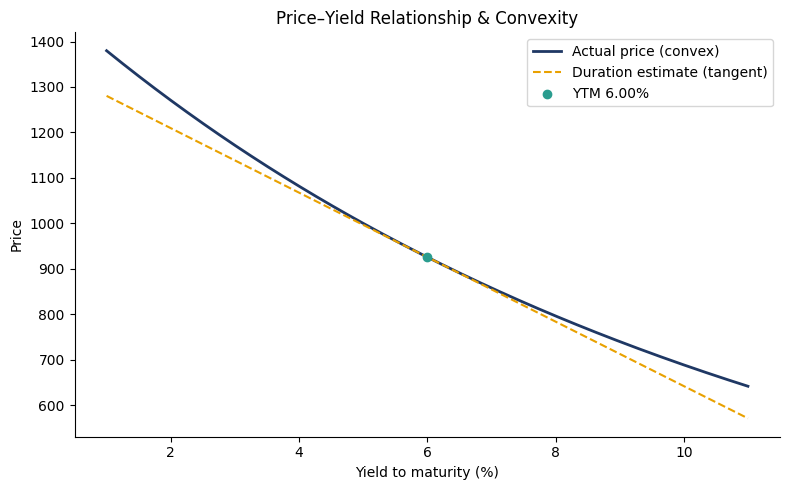


Comparing four bonds:


,Bond,Coupon,Years,YTM,Price,Mod Dur,Convexity,DV01
0,A · 3y 4%,4.00%,3,5.000%,972.46,2.785,9.35,0.2708
1,B · 10y 5%,5.00%,10,6.000%,925.61,7.665,71.79,0.7095
2,C · 30y 6%,6.00%,30,6.500%,934.37,13.319,279.77,1.2445
3,D · 5y zero,0.00%,5,4.500%,800.51,4.890,26.30,0.3914


In [9]:
print("Bond summary (1000 face, 5% semiannual coupon, 10y, 6% YTM)\n")
d = summary(1000, 0.05, 10, ytm_=0.06)

print("\nIf the YTM rises 50 bp, estimated vs actual new price:")
pct, est = est_price_change(d['price'], d['modified'], d['convexity'], 0.005)
actual = bond_price(1000, 0.05, 10, 0.065)
print(f"  duration+convexity estimate = {est:.4f}   full reprice = {actual:.4f}")

plot_price_yield(1000, 0.05, 10, 0.06)

print("\nComparing four bonds:")
compare_bonds([
    {'name': 'A · 3y 4%',   'face': 1000, 'coupon': 0.04, 'years': 3,  'ytm': 0.05},
    {'name': 'B · 10y 5%',  'face': 1000, 'coupon': 0.05, 'years': 10, 'ytm': 0.06},
    {'name': 'C · 30y 6%',  'face': 1000, 'coupon': 0.06, 'years': 30, 'ytm': 0.065},
    {'name': 'D · 5y zero', 'face': 1000, 'coupon': 0.00, 'years': 5,  'ytm': 0.045},
])